# Extract Recovered Symbolic Model

In [1]:
import sympy as sp
import torch
import dill
from pathlib import Path

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------
SAVE_PATH = Path("models/frf_model_full.pt")
device = "cpu"

ckpt = torch.load(
    SAVE_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

feature_tokens = ckpt["feature_tokens"]
test_mse = ckpt["test_mse"]
expr_str = ckpt["expr"]

# ------------------------------------------------------------
# symbolic variables exactly as in training
# ------------------------------------------------------------
omega = sp.Symbol("omega")
phi = sp.Symbol("phi")
damage = sp.Symbol("d")

name_map = {
    "f": omega,
    "sin_phase": sp.sin(phi),
    "cos_phase": sp.cos(phi),
    "damage": damage,
}

symbolic_inputs = [name_map[t] for t in feature_tokens]
omega = name_map["f"]
aux_inputs = symbolic_inputs[1:]

# ------------------------------------------------------------
# helper
# ------------------------------------------------------------
def coef(w: torch.Tensor, decimals: int = 5):
    return round(float(w.real.detach().cpu().item()), decimals)

# ------------------------------------------------------------
# build expression manually
# ------------------------------------------------------------
a = coef(model.a)
b = coef(model.b)

expr = a * omega + b

for block in model.resonators:
    A = coef(block.A)
    gamma = coef(block.gamma)

    h = block.eql.get_symbolic_expression(
        aux_inputs,
        rounding_decimals=5,
        use_imag=False,
    )

    expr = expr + A / ((omega - h) ** 2 + gamma)

# ------------------------------------------------------------
# build equation
# ------------------------------------------------------------
Hhat = sp.Function(r"\hat{H}")
lhs = Hhat(*symbolic_inputs)
eq = sp.Eq(lhs, expr)

# ------------------------------------------------------------
# output
# ------------------------------------------------------------
print("Feature tokens:", feature_tokens)
print("Test MSE:", test_mse)

print("\nCheckpoint expr string:")
print(expr_str)

print("\nRebuilt symbolic expression:")
print(expr)

print("\nEquation:")
print(eq)

print("\nLaTeX:\n")
print(r"\begin{equation}")
print(sp.latex(eq))
print(r"\end{equation}")

Feature tokens: ['f', 'damage']
Test MSE: 13.063483238220215

Checkpoint expr string:
5.21654*omega - 0.3154 + 0.08445/(1.0e-5*d**5 - 0.0014*d**4*omega + 0.00123*d**4 + 0.00434*d**3*omega - 0.00386*d**3 + 1.0e-5*d**2 - 0.00772*d*omega + 0.00687*d + 1.0*omega**2 - 1.78*omega + 0.77585) + 0.0577/(0.0031*d**4 - 0.02881*d**3 + 0.11144*d**2*omega - 0.07405*d**2 - 0.51708*d*omega + 0.65372*d + 1.0*omega**2 - 2.5285*omega + 1.45843) + 0.47169/(0.00119*d**4 - 0.02577*d**3 + 0.06912*d**2*omega + 0.15093*d**2 - 0.74578*d*omega - 0.12823*d + 1.0*omega**2 + 0.34388*omega - 0.33407) - 0.76141/(0.00099*d**4 - 0.00562*d**3 - 0.06292*d**2*omega + 0.03953*d**2 + 0.17874*d*omega - 0.08962*d + 1.0*omega**2 - 1.00276*omega + 0.29796) + 2.42351/(0.00065*d**4 - 0.0031*d**3 - 0.05082*d**2*omega + 0.01564*d**2 + 0.122*d*omega - 0.02862*d + 1.0*omega**2 - 0.46924*omega + 0.02115) + 0.08136/(0.2711*d**2 - 1.04134*d*omega + 0.79497*d + 1.0*omega**2 - 1.52682*omega + 0.43463) + 0.48817/(0.07378*d**2 - 0.54324*d*o

In [2]:
eq

Eq(\hat{H}(omega, d), 5.21654*omega - 0.3154 + 0.08445/((-0.0007*d**4 + 0.00217*d**3 - 0.00386*d + omega - 0.89)**2 - 0.01625) + 0.0577/((0.05572*d**2 - 0.25854*d + omega - 1.26425)**2 - 0.1399) + 0.47169/((0.03456*d**2 - 0.37289*d + omega + 0.17194)**2 - 0.36363) + 2.42351/((-0.02541*d**2 + 0.061*d + omega - 0.23462)**2 - 0.0339) - 0.76141/((-0.03146*d**2 + 0.08937*d + omega - 0.50138)**2 + 0.04658) - 0.26376/((-0.20983*d + omega - 0.76732)**2 + 0.00551) + 0.48817/((-0.27162*d + omega - 0.20312)**2 + 0.31504) + 0.08136/((-0.52067*d + omega - 0.76341)**2 - 0.14816) + 0.29455/((omega - 0.69792)**2 + 0.06101))

In [3]:
import sympy as sp

# ------------------------------------------------------------
# symbolic variables consistent with training
# ------------------------------------------------------------
phi = sp.Symbol("phi")
damage = sp.Symbol("d")

symbol_map = {
    "sin_phase": sp.sin(phi),
    "cos_phase": sp.cos(phi),
    "damage": damage,
}

symbolic_inputs_aux = [
    symbol_map["damage"],
]

# ------------------------------------------------------------
# print symbolic g_i functions
# ------------------------------------------------------------
for i, block in enumerate(model.resonators, start=1):

    g_expr = block.eql.get_symbolic_expression(
        symbolic_inputs_aux,
        rounding_decimals=5,
        use_imag=False,
    )

    print(f"g_{i} = {g_expr}\n")

    latex_expr = sp.latex(g_expr)

    print("LaTeX:")
    print(rf"g_{{{i}}} = {latex_expr}")

g_1 = 0.69792

LaTeX:
g_{1} = 0.69792
g_2 = 0.02541*d**2 - 0.061*d + 0.23462

LaTeX:
g_{2} = 0.02541 d^{2} - 0.061 d + 0.23462
g_3 = 0.20983*d + 0.76732

LaTeX:
g_{3} = 0.20983 d + 0.76732
g_4 = -0.03456*d**2 + 0.37289*d - 0.17194

LaTeX:
g_{4} = - 0.03456 d^{2} + 0.37289 d - 0.17194
g_5 = 0.03146*d**2 - 0.08937*d + 0.50138

LaTeX:
g_{5} = 0.03146 d^{2} - 0.08937 d + 0.50138
g_6 = 0.52067*d + 0.76341

LaTeX:
g_{6} = 0.52067 d + 0.76341
g_7 = -0.05572*d**2 + 0.25854*d + 1.26425

LaTeX:
g_{7} = - 0.05572 d^{2} + 0.25854 d + 1.26425
g_8 = 0.0007*d**4 - 0.00217*d**3 + 0.00386*d + 0.89

LaTeX:
g_{8} = 0.0007 d^{4} - 0.00217 d^{3} + 0.00386 d + 0.89
g_9 = 0.27162*d + 0.20312

LaTeX:
g_{9} = 0.27162 d + 0.20312


# Visualize FRF predictions

Loaded model: models/frf_model_full.pt
Feature tokens: ['f', 'damage']
Healthy file: P-1.txt
Damaged file: P-1-2.txt


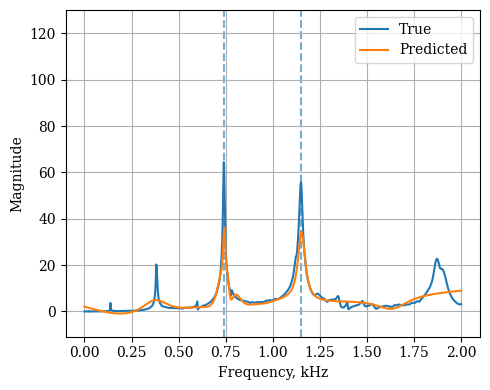

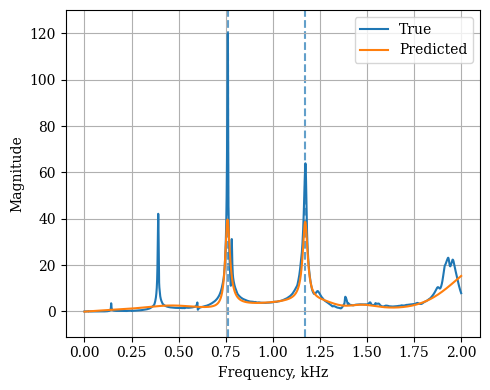

In [8]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List

import dill
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl


# ============================================================
# Paths
# ============================================================
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

DATA = ROOT / "frf_data"

FRF_FOLDERS = {
    "healthy": DATA / "1-Beam_healthy",
    "damage_2.96": DATA / "2-Beam_damage_2.96",
    "damage_5.92": DATA / "3-Beam_damage_5.92",
    "damage_8.87": DATA / "4-Beam_damage_8.87",
}

HEALTHY_FOLDER = FRF_FOLDERS["healthy"]
DAMAGED_FOLDER = FRF_FOLDERS["damage_5.92"]

MODEL_PATH = Path("models/frf_model_full.pt")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


# ============================================================
# Peak detection configuration
# ============================================================
PEAK_CENTERS = [0.75, 1.18]  # kHz
PEAK_WINDOW = 0.1            # kHz


# ============================================================
# Device
# ============================================================
device = torch.device("cpu")


# ============================================================
# Load model
# ============================================================
ckpt = torch.load(
    MODEL_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

FEATURE_TOKENS = ckpt["feature_tokens"]

print("Loaded model:", MODEL_PATH)
print("Feature tokens:", FEATURE_TOKENS)


# ============================================================
# Damage levels
# ============================================================
DAMAGE_LEVEL = {
    "healthy": 0.0,
    "damage_2.96": 2.96,
    "damage_5.92": 5.92,
    "damage_8.87": 8.87,
}


# ============================================================
# Robust FRF TXT reader
# ============================================================
_NUM = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?")
_RE_FILE = re.compile(r"^P-(\d+)(?:-(\d+))?$")


def read_frf_txt(path: Path):

    text = path.read_bytes().decode("latin-1", errors="ignore")

    f_list, m_list, p_list = [], [], []

    for line in text.splitlines():

        line = line.strip()
        if not line:
            continue

        nums = _NUM.findall(line)
        if len(nums) < 3:
            continue

        f = float(nums[0])
        mag = float(nums[1])
        ph = float(nums[2])

        if not (np.isfinite(f) and np.isfinite(mag) and np.isfinite(ph)):
            continue

        f_list.append(f)
        m_list.append(mag)
        p_list.append(ph)

    f = np.asarray(f_list)
    mag = np.asarray(m_list)
    ph = np.asarray(p_list)

    idx = np.argsort(f)

    return f[idx], mag[idx], ph[idx]


def parse_file_id(fp: Path):
    m = _RE_FILE.match(fp.stem)
    if not m:
        raise ValueError(f"Unexpected FRF filename: {fp.name}")

    sample = int(m.group(1))
    suffix = int(m.group(2)) if m.group(2) is not None else 0

    return sample, suffix


# ============================================================
# Feature construction (identical to training)
# ============================================================
def db_to_linear_mag(mag_db: np.ndarray):
    return np.power(10.0, mag_db / 20.0)


def build_feature_matrix(
    *,
    f: np.ndarray,
    mag_db: np.ndarray,
    ph_deg: np.ndarray,
    cond: str,
):

    phi = np.deg2rad(ph_deg)

    sinp = np.sin(phi)
    cosp = np.cos(phi)

    damage = DAMAGE_LEVEL[cond]

    feature_bank: Dict[str, np.ndarray] = {

        "f": (f / 1000.0).astype(np.float32),

        "sin_phase": sinp.astype(np.float32),

        "cos_phase": cosp.astype(np.float32),

        "damage": np.full_like(f, damage, dtype=np.float32),

    }

    X = np.concatenate(
        [feature_bank[t].reshape(-1, 1) for t in FEATURE_TOKENS],
        axis=1,
    ).astype(np.float32)

    y = db_to_linear_mag(mag_db).astype(np.float32).reshape(-1, 1)

    return X, y


# ============================================================
# Prediction
# ============================================================
def predict_curve(fp: Path, cond: str):

    f, mag_db, ph_deg = read_frf_txt(fp)

    X, y_lin = build_feature_matrix(
        f=f,
        mag_db=mag_db,
        ph_deg=ph_deg,
        cond=cond,
    )

    f_idx = FEATURE_TOKENS.index("f")
    f_plot = X[:, f_idx]

    with torch.no_grad():

        Xc = torch.from_numpy(X).float().to(device)

        pred = model(Xc).real

        pred_lin = pred.detach().cpu().numpy().reshape(-1)

    y_lin = y_lin.reshape(-1)

    order = np.argsort(f_plot)

    return f_plot[order], y_lin[order], pred_lin[order]


# ============================================================
# Peak detection
# ============================================================
def detect_target_peaks(freq, y_true):

    peak_freqs = []

    for center in PEAK_CENTERS:

        mask = np.abs(freq - center) <= PEAK_WINDOW

        if not np.any(mask):
            peak_freqs.append(np.nan)
            continue

        local_freq = freq[mask]
        local_true = y_true[mask]

        idx = np.argmax(local_true)

        peak_freqs.append(local_freq[idx])

    return np.array(peak_freqs)


# ============================================================
# Select files
# ============================================================
healthy_file = sorted(HEALTHY_FOLDER.glob("*.txt"))[0]
damaged_file = sorted(DAMAGED_FOLDER.glob("*.txt"))[0]

print("Healthy file:", healthy_file.name)
print("Damaged file:", damaged_file.name)


# ============================================================
# Predict curves
# ============================================================
f_h, y_h, pred_h = predict_curve(healthy_file, "healthy")
f_d, y_d, pred_d = predict_curve(damaged_file, "damage_5.92")


# ============================================================
# Detect peaks
# ============================================================
peaks_h = detect_target_peaks(f_h, y_h)
peaks_d = detect_target_peaks(f_d, y_d)


# ============================================================
# Shared limits
# ============================================================
y_min = min(y_h.min(), y_d.min(), pred_h.min(), pred_d.min()) - 10
y_max = max(y_h.max(), y_d.max(), pred_h.max(), pred_d.max()) + 10


# ============================================================
# Plot style
# ============================================================
mpl.rcParams["font.family"] = "serif"

true_color = "tab:blue"
pred_color = "tab:orange"


# ============================================================
# Healthy plot
# ============================================================
plt.figure(figsize=(5,4))

# background peak lines
for p in peaks_h:
    if np.isfinite(p):
        plt.axvline(
            p,
            linestyle="--",
            color=true_color,
            alpha=0.6,
            zorder=0,
        )

plt.plot(f_h, y_h, label="True", color=true_color, zorder=3)
plt.plot(f_h, pred_h, label="Predicted", color=pred_color, zorder=3)

plt.xlabel("Frequency, kHz")
plt.ylabel("Magnitude")

plt.ylim(y_min, y_max)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(FIG_DIR / "frf_prediction_healthy.pdf", bbox_inches="tight")

plt.show()


# ============================================================
# Damaged plot
# ============================================================
plt.figure(figsize=(5,4))

# background peak lines
for p in peaks_d:
    if np.isfinite(p):
        plt.axvline(
            p,
            linestyle="--",
            color=true_color,
            alpha=0.7,
            zorder=0,
        )

plt.plot(f_d, y_d, label="True", color=true_color, zorder=3)
plt.plot(f_d, pred_d, label="Predicted", color=pred_color, zorder=3)

plt.xlabel("Frequency, kHz")
plt.ylabel("Magnitude")

plt.ylim(y_min, y_max)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(FIG_DIR / "frf_prediction_damaged.pdf", bbox_inches="tight")

plt.show()